# Основы глубинного обучения, майнор ИАД

## Домашнее задание 1: полносвязные сети

**ФИО:** Литвинова Мария Евгеньевна

**Факт о себе:** за колу зеро готова на воровство


## Общая информация

__Дата выдачи:__ 22.09.2025

__Мягкий дедлайн:__ 23:59MSK 12.10.2025

__Жесткий дедлайн:__ 23:59MSK 19.10.2025


## Оценивание и штрафы

Максимально допустимая оценка за работу — 10 баллов. Сдавать задание после указанного срока сдачи нельзя.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов. Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).  Если два студента сгенерировали в нейронке одинаковые либо похожие решения, это считается плагиатом и приводит к обнулению обеих работ.

Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо оформленные графики. Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

Итогова оценка считается как

$$
min(part_1, part_2) \cdot 0.6 + max(part_1, part_2) \cdot 0.2 + part_3 \cdot 0.2
$$

где $part_1$, $part_2$ и $part_3$ - оценки за первую, вторую и третью части работы

> Также, за домашнее задание выставляется 0, если не сделано нулевое задание либо нет подробного описания ваших экспериментов в третьей части.

## Оформление

1. Обязательно фиксируйте зерно генератора случайных чисел в экспериментах. При перезапуске кода значения не должны меняться.
2. Вверху файла подпишите фамилию, имя и какой-то занимательный факт о себе.
3. Обратите внимание, что у графиков должны быть подписаны оси, заголовок графика и при необходимости обязательно наличие легенды.

> За отсутствие названий графиков и подписей к осям могут снижаться баллы. Все картинки должны быть самодостаточны и визуально удобны для восприятия, так чтобы не нужно было смотреть ваш код или знать задание, чтобы понять что на них изображено.

Из каждого проведённого эксперимента делайте выводы и фиксируйте их. Эти выводы не должны быть поверхностными и очевидными. Не будьте мудрым королём.

<br>

<center>
<img src="https://raw.githubusercontent.com/hse-ds/iad-deep-learning/refs/heads/master/2025/homeworks/king.png" width="300">
</center>

**Пример плохого вывода:** Синенькая линия идет вверх, а красная вниз. Черненькая идет вниз, а потом вверх.

<br>

<center>
<img src="https://raw.githubusercontent.com/hse-ds/iad-deep-learning/refs/heads/master/2025/homeworks/bad_lines.png" width="600">
</center>

## О задании

Вам предстоит обучить полносвязную нейронную сеть для предсказания года выпуска песни по ее аудио-признакам. Для этого мы будем использовать [Million Songs Dataset](https://samyzaf.com/ML/song_year/song_year.html).

In [ ]:
import torch
from torch import nn
import torch.nn.functional as F

import pandas as pd
import numpy as np
import random

from tqdm.notebook import tqdm
from IPython.display import clear_output
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

Начнем с того, что скачаем и загрузим данные:

In [ ]:
!wget -O yearpredictionmsd.zip https://archive.ics.uci.edu/static/public/203/yearpredictionmsd.zip

--2025-10-19 18:32:08--  https://archive.ics.uci.edu/static/public/203/yearpredictionmsd.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘yearpredictionmsd.zip’

yearpredictionmsd.z     [                <=> ] 201.24M  17.3MB/s    in 12s     

2025-10-19 18:32:22 (16.3 MB/s) - ‘yearpredictionmsd.zip’ saved [211011981]



In [ ]:
df = pd.read_csv('yearpredictionmsd.zip', header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,81,82,83,84,85,86,87,88,89,90
0,2001,49.94357,21.47114,73.07750,8.74861,-17.40628,-13.09905,-25.01202,-12.23257,7.83089,...,13.01620,-54.40548,58.99367,15.37344,1.11144,-23.08793,68.40795,-1.82223,-27.46348,2.26327
1,2001,48.73215,18.42930,70.32679,12.94636,-10.32437,-24.83777,8.76630,-0.92019,18.76548,...,5.66812,-19.68073,33.04964,42.87836,-9.90378,-32.22788,70.49388,12.04941,58.43453,26.92061
2,2001,50.95714,31.85602,55.81851,13.41693,-6.57898,-18.54940,-3.27872,-2.35035,16.07017,...,3.03800,26.05866,-50.92779,10.93792,-0.07568,43.20130,-115.00698,-0.05859,39.67068,-0.66345
3,2001,48.24750,-1.89837,36.29772,2.58776,0.97170,-26.21683,5.05097,-10.34124,3.55005,...,34.57337,-171.70734,-16.96705,-46.67617,-12.51516,82.58061,-72.08993,9.90558,199.62971,18.85382
4,2001,50.97020,42.20998,67.09964,8.46791,-15.85279,-16.81409,-12.48207,-9.37636,12.63699,...,9.92661,-55.95724,64.92712,-17.72522,-1.49237,-7.50035,51.76631,7.88713,55.66926,28.74903


Посмотрим на статистики по данным.

In [ ]:
df.describe()

,0,1,2,3,4,5,6,7,8,9,...,81,82,83,84,85,86,87,88,89,90
count,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,...,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000
mean,1998.397082,43.387126,1.289554,8.658347,1.164124,-6.553601,-9.521975,-2.391089,-1.793236,3.727876,...,15.755406,-73.461500,41.542422,37.934119,0.315751,17.669213,-26.315336,4.458641,20.035136,1.329105
std,10.931046,6.067558,51.580351,35.268585,16.322790,22.860785,12.857751,14.571873,7.963827,10.582861,...,32.099635,175.618889,122.228799,95.050631,16.161764,114.427905,173.977336,13.346557,185.558247,22.088576
min,1922.000000,1.749000,-337.092500,-301.005060,-154.183580,-181.953370,-81.794290,-188.214000,-72.503850,-126.479040,...,-437.722030,-4402.376440,-1810.689190,-3098.350310,-341.789120,-3168.924570,-4319.992320,-236.039260,-7458.378150,-381.424430
25%,1994.000000,39.954690,-26.059520,-11.462710,-8.487500,-20.666450,-18.440990,-10.780600,-6.468420,-2.293660,...,-1.812650,-139.555160,-20.986900,-4.669540,-6.781590,-31.580610,-101.530300,-2.566090,-59.509270,-8.820210
50%,2002.000000,44.258500,8.417850,10.476320,-0.652840,-6.007770,-11.188390,-2.046670,-1.736450,3.822310,...,9.171850,-53.090060,28.791060,33.623630,0.820840,15.598470,-21.204120,3.117640,7.759730,0.053050
75%,2006.000000,47.833890,36.124010,29.764820,8.787540,7.741870,-2.388960,6.508580,2.913450,9.961820,...,26.274480,13.478730,89.661770,77.785800,8.470990,67.794960,52.389330,9.967740,86.351610,9.679520
max,2011.000000,61.970140,384.065730,322.851430,335.771820,262.068870,166.236890,172.402680,126.741270,146.297950,...,840.973380,4469.454870,3210.701700,1734.079690,260.544900,3662.065650,2833.608950,463.419500,7393.398440,677.899630


Целевая переменная, год выпуска песни, записана в первом столбце. Посмотрим на ее распределение.

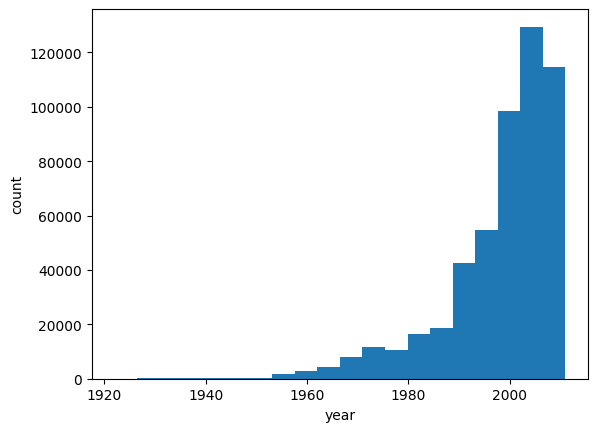

Range: 1922 - 2011
Unique values: 89


In [ ]:
plt.hist(df.iloc[:, 0], bins=20)
plt.xlabel('year')
plt.ylabel('count')
plt.show()
print(f'Range: {df.iloc[:, 0].min()} - {df.iloc[:, 0].max()}')
print(f'Unique values: {np.unique(df.iloc[:, 0]).size}')

Разобьем данные на обучение и тест (не меняйте здесь ничего, чтобы сплит был одинаковым у всех).

In [ ]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

train_size = int(0.75 * X.shape[0])

X_train = X[:train_size, :]
y_train = y[:train_size]
X_test = X[train_size:, :]
y_test = y[train_size:]

X_train.shape, X_test.shape

((386508, 90), (128837, 90))

## Полезные советы:

- Если вы сразу реализуете обучение на GPU, то у вас будет больше времени на эксперименты, так как любые вычисления будут работать быстрее. Google Colab предоставляет несколько GPU-часов (обычно около 8-10) в сутки бесплатно.

- Если вы чего-то не знаете, не стесняйтесь гуглить. В интернете очень много полезной информации, туториалов и советов по глубинному обучению и `pytorch`. Но не забывайте, что за списанный код без ссылки на источник последует наказание.

- Чтобы отладить код, можете обучаться на небольшой части данных или даже на одном батче. Если лосс на обучающей выборке не падает, то что-то точно идет не так.

- Пользуйтесь утилитами, которые вам предоставляет `pytorch` (например, `Dataset` и `Dataloader`). Их специально разработали для упрощения разработки пайплайна обучения.

- Скорее всего, вы захотите отслеживать прогресс обучения. Для создания прогресс-баров есть удобная библиотека `tqdm`.

- Быть может, вы захотите, чтобы графики рисовались прямо во время обучения. Можете воспользоваться функцией [clear_output](http://ipython.org/ipython-doc/dev/api/generated/IPython.display.html#IPython.display.clear_output), чтобы удалять старый график и рисовать новый на его месте.

- При желании вы можете логгировать метрики обучения и свои эксперименты в WandB либо любой другой сервис. Не забудьте приложить к тетрадке ссылку на результаты экспериментов либо скришноты графиков с пояснениями, что проверяющий должен на них увидеть.

- Финальное значение тестовой метрики для удобства проверки выведите в тетрадке.

## Задание 0 (0 баллов, но при невыполнении максимальная оценка за всю работу &mdash; 0 баллов)

Мы будем использовать RMSE как метрику качества. Прежде чем обучать нейронные сети, нам нужно проверить несколько простых бейзлайнов, чтобы было с чем сравнить более сложные алгоритмы. Для этого бучите `Ridge` регрессию из `sklearn`. Кроме того, посчитайте качество при наилучшем константном прогнозе.

Для выполнения данного задания (и всех последующих) предобработайте данные.

1. Зафиксируйте random_seed везде где только возможно. Вам предоставлена функция для этого, однако вы можете дополнить ее своими дополнениями.
2. Обучите `StandertScaler` и предобработайте ваши данные. В следующих заданиях можете использовать другой `scaler` или вообще отказаться от него.


In [ ]:
def set_global_seed(seed: int) -> None:
    """Set global seed for reproducibility.
    :param int seed: Seed to be set
    """
    torch.backends.cudnn.deterministic = True
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)

    # также можно зафиксировать seed для Dataloader
    g = torch.Generator()
    g.manual_seed(seed)
    return g

# Сид для каждого worker в Dataloader
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = set_global_seed(42)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = Ridge(alpha = 1.0, random_state = 42).fit(X_train_scaled, y_train)
y_pred_ridge = model.predict(X_test_scaled)
rmse_for_model = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

rmse_for_model

np.float64(9.473630332684092)

Лучшая константа для RMSE это среднее. Используйте среднее, расчитанное на трэйне в качестве прогноза для теста и посчитайте для такой наивной модели RMSE.

In [ ]:
const_pred = np.mean(y_train)
const_pred_test = np.full_like(y_test, const_pred)
best_rmse_metric = np.sqrt(mean_squared_error(y_test, const_pred_test))

print(f'RMSE для массива со средними значениями: {round(best_rmse_metric, 4)}')

RMSE для массива со средними значениями: 10.855


Теперь приступим к экспериментам с нейросетями. Для начала отделим от данных валидацию. Тестовую выборку мы будем использовать только для того, чтобы измерить итоговую метрику качества модели.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=0xE2E4)
X_train.shape, X_val.shape

((289881, 90), (96627, 90))

## Часть I. Обучаем линейную регрессию (максимум 10 баллов)

**Задание 1 (10 баллов):** Обучите в `pytorch` линейную регрессию.

- Создайте модель линейной регрессии, которая будет состоять только из одного `Linear()` слоя.
   
- Напишите цикл обучения вашей линейной регрессии. В нем реализуйте подсчет функции потерь, сделайте шаг градиентного спуска. Запрещено использовать готовые оптимизаторы и loss-функции из библиотеки `pytorch`. Для подсчета градиента воспользуйтесь методом backward.
   
- Запустите обучение на 10 эпохах, после каждой проверяйте значение целевой метрики на тестовой выборке.
   
- Выведите на экран графики метрики и значения функции потерь на тестовой и обучающей выборке.

В данном задании нет цели побить какой-то порог по метрике. Ваша задача &mdash; убедиться в том, что ваш рукописный цикл обучения работает. Для ускорения вычислений и обучения модели можете брать только срез данных, а не весь датасет.

Эпоха 1:
Train Loss: 3993997.50
Train RMSE: 1998.50
Test Loss: 3248781.75
Test RMSE: 1802.44
 
Эпоха 2:
Train Loss: 3212561.50
Train RMSE: 1792.36
Test Loss: 2642505.25
Test RMSE: 1625.58
 
Эпоха 3:
Train Loss: 2594183.25
Train RMSE: 1610.65
Test Loss: 2150838.25
Test RMSE: 1466.57
 
Эпоха 4:
Train Loss: 2098889.50
Train RMSE: 1448.75
Test Loss: 1751318.50
Test RMSE: 1323.37
 
Эпоха 5:
Train Loss: 1700355.75
Train RMSE: 1303.98
Test Loss: 1426548.38
Test RMSE: 1194.38
 
Эпоха 6:
Train Loss: 1378852.25
Train RMSE: 1174.25
Test Loss: 1162440.00
Test RMSE: 1078.17
 
Эпоха 7:
Train Loss: 1119052.50
Train RMSE: 1057.85
Test Loss: 947595.94
Test RMSE: 973.45
 
Эпоха 8:
Train Loss: 908857.31
Train RMSE: 953.34
Test Loss: 772775.12
Test RMSE: 879.08
 
Эпоха 9:
Train Loss: 738631.94
Train RMSE: 859.44
Test Loss: 630478.56
Test RMSE: 794.03
 
Эпоха 10:
Train Loss: 600664.75
Train RMSE: 775.03
Test Loss: 514618.09
Test RMSE: 717.37
 


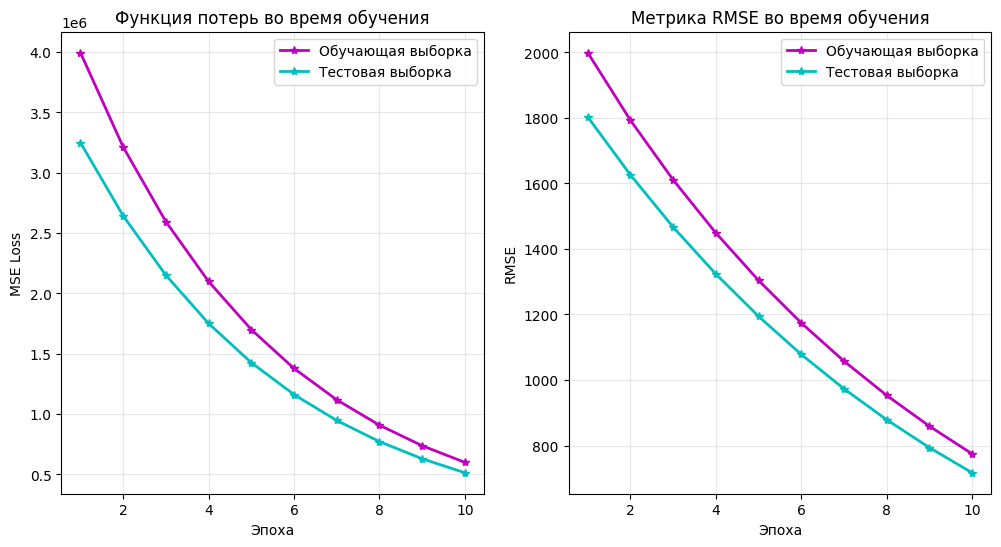

Final Train RMSE: 775.03
Final Test RMSE: 717.37
Сравнение с бейзлайнами:
Наивная модель: 10.86
Ridge регрессия: 9.47
PyTorch Linear: 717.37


In [ ]:
g = set_global_seed(42)

sample_size = 10000
X_train_sample = X_train_scaled[:sample_size]
y_train_sample = y_train[:sample_size]
X_test_sample = X_test_scaled[:sample_size//2]
y_test_sample = y_test[:sample_size//2]

X_train_tensor = torch.tensor(X_train_sample, device=device, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_sample, device=device, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_sample, device=device, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_sample, device=device, dtype=torch.float32)


in_features = X_train_tensor.shape[1]
out_features = 1
model = torch.nn.Linear(in_features = in_features, out_features = out_features).to(device)


with torch.no_grad():
  model.weight.normal_(0, 0.01)
  model.bias.zero_()

epochs = 10

train_losses = []
test_losses = []
train_rmses = []
test_rmses = []

for i in range(epochs):
  model.train()
  y_pred_train = model(X_train_tensor).squeeze()
  loss_train = torch.mean((y_pred_train - y_train_tensor) ** 2)
  model.zero_grad()
  loss_train.backward()

  with torch.no_grad():
    for param in model.parameters():
      param -= 0.05 * param.grad

  model.eval()
  with torch.no_grad():
    y_pred_test = model(X_test_tensor).squeeze()
    loss_test = torch.mean((y_pred_test - y_test_tensor) ** 2)

  rmse_train = torch.sqrt(loss_train)
  rmse_test = torch.sqrt(loss_test)

  train_losses.append(loss_train.item())
  test_losses.append(loss_test.item())
  train_rmses.append(rmse_train.item())
  test_rmses.append(rmse_test.item())

  print(f'Эпоха {i+1}:')
  print(f'Train Loss: {loss_train.item():.2f}')
  print(f'Train RMSE: {rmse_train.item():.2f}')
  print(f'Test Loss: {loss_test.item():.2f}')
  print(f'Test RMSE: {rmse_test.item():.2f}')
  print(' ')

plt.figure(figsize=(12, 6))
#MSE
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs+1), train_losses, 'm-*', label='Обучающая выборка', linewidth = 2)
plt.plot(range(1, epochs+1), test_losses, 'c-*', label='Тестовая выборка', linewidth = 2)
plt.xlabel('Эпоха')
plt.ylabel('MSE Loss')
plt.title('Функция потерь во время обучения')
plt.legend()
plt.grid(True, alpha=0.3)
#RMSE
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs+1), train_rmses, 'm-*', label='Обучающая выборка', linewidth = 2)
plt.plot(range(1, epochs+1), test_rmses, 'c-*', label='Тестовая выборка', linewidth = 2)
plt.xlabel('Эпоха')
plt.ylabel('RMSE')
plt.title('Метрика RMSE во время обучения')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

print(f'Final Train RMSE: {train_rmses[-1]:.2f}')
print(f'Final Test RMSE: {test_rmses[-1]:.2f}')
print(f'Сравнение с бейзлайнами:')
print(f'Наивная модель: {best_rmse_metric :.2f}')
print(f'Ridge регрессия: {rmse_for_model:.2f}')
print(f'PyTorch Linear: {test_rmses[-1]:.2f}')

## Часть II. Заводим нейронную сеть (максимум 10 баллов)

Ниже нам предстоит реализовать довольно много различных нейросетей и поставить целую серию экспериментов. Чтобы это всё происходило без боли и страданий, нам нужно держать код в удобном виде.

При решении заданий вы можете придерживаться любой адекватной струкуры кода, но мы советуем воспользоваться сигнатурами функций, которые приведены ниже. При необходимости вы можете добавить в них любые нужные вам аргументы и любой нужный функционал. Более того, хорошей практикой является не делать эти функции слишком громоздкими и выносить разные хитрые штуки в отдельные функции.

In [ ]:
def training_epoch(model, optimizer, criterion, train_loader):
    """Одна эпоха обучения
    params:
        model - torch.nn.Module to be fitted
        optimizer - model optimizer
        criterion - loss function from torch.nn
        train_loader - torch.utils.data.Dataloader with train set
    """
    model.train()
    total_loss = 0.0
    num_batches = 0

    for batch_X, batch_y in train_loader:
      optimizer.zero_grad()
      predictions = model(batch_X).squeeze()
      loss = criterion(predictions, batch_y)
      loss.backward()
      optimizer.step()

      total_loss += loss.item()
      num_batches += 1

    return total_loss / num_batches

    raise NotImplementedError


@torch.no_grad()
def validation_epoch(model, criterion, val_loader):
    """Одна эпоха валидации модели
    params:
        model - torch.nn.Module to be fitted
        criterion - loss function from torch.nn
        val_loader - torch.utils.data.Dataloader with test set
                      (if you wish to validate during training)
    """

    model.eval()
    total_loss = 0.0
    num_batches = 0

    for batch_X, batch_y in val_loader:
      predictions = model(batch_X).squeeze()
      loss = criterion(predictions, batch_y)
      total_loss += loss.item()
      num_batches += 1

    return total_loss / num_batches

    raise NotImplementedError


@torch.no_grad()
def predict(model, data_loader):
    """ Предсказания модели
    params:
        model - torch.nn.Module to be evaluated on test set
        criterion - loss function from torch.nn
        data_loader - torch.utils.data.Dataloader with test set
    ----------
    returns:
        predicts - torch.tensor with shape (len(test_loader.dataset), ),
                   which contains predictions for test objects
    """

    model.eval()
    all_predictions = []

    for batch_X, _ in data_loader:
      predictions = model(batch_X).squeeze()
      all_predictions.append(predictions)

    predicts = torch.cat(all_predictions)

    predicts = torch.ones(len(test_loader.dataset))
    return predicts


def train(model, optimizer, criterion, train_loader, val_loader, epochs):
    """ Обучение модели
    params:
        model - torch.nn.Module to be fitted
        optimizer - model optimizer
        criterion - loss function from torch.nn
        train_loader - torch.utils.data.Dataloader with train set
        val_loader - torch.utils.data.Dataloader with test set
                      (if you wish to validate during training)
        epochs - number of training epochs
    """

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
      train_loss = training_epoch(model, optimizer, criterion, train_loader)
      val_loss = validation_epoch(model, criterion, val_loader)

      train_losses.append(train_loss)
      val_losses.append(val_loss)

      print(f'Эпоха {epoch+1}:')
      print(f'Train Loss: {train_loss:.4f}')
      print(f'Validation Loss: {val_loss:.4f}')

    return train_losses, val_losses

    raise NotImplementedError

**Задание 2 (2 балла)**

Попробуем обучить нашу первую нейронную сеть. Здесь целевая переменная дискретная &mdash; это год выпуска песни. Поэтому будем учить сеть на классификацию.

- В качестве архитектуры сети возьмите два линейных слоя с активацией ReLU между ними c числом скрытых нейронов, равным 128.
- Используйте SGD с `lr=1e-3`.
- Возьмите размер мини-батча около 32-64, примерно 3-4 эпох обучения должно быть достаточно.
- Также преобразуйте целевую переменную так, чтобы ее значения принимали значения от $0$ до $C-1$, где $C$ &mdash; число классов (лучше передайте преобразованное значение в DataLoader, исходное нам еще пригодится)
- В качестве метрики качества мы используем RMSE. При его подсчёте вам нужно заменить предсказанный нейросеткой класс на конкретный год выпуска песни и использовать его как прогноз.

In [ ]:
g = set_global_seed(42)

X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(X_train, y_train, test_size=0.25, random_state=0xE2E4)

X_train_scaled = scaler.fit_transform(X_train_split)
X_val_scaled = scaler.transform(X_val_split)
X_test_scaled = scaler.transform(X_test)

y_train_min = y_train.min()
y_train_max = y_train.max()
num_classes = y_train_max - y_train_min + 1

y_train_class = y_train_split - y_train_min # годы в классы
y_val_class = y_val_split - y_train_min
y_test_class = y_test - y_train_min

class AudioDataset(torch.utils.data.Dataset):
    def __init__(self, features, targets):
      self.features = torch.FloatTensor(features)
      self.targets = torch.LongTensor(targets)

    def __len__(self):
      return len(self.features)

    def __getitem__(self, idx):
      return self.features[idx], self.targets[idx]

batch_size = 64
train_dataset = AudioDataset(X_train_scaled, y_train_class)
val_dataset = AudioDataset(X_val_scaled, y_val_class)
test_dataset = AudioDataset(X_test_scaled, y_test_class)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, worker_init_fn=seed_worker, generator=g)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False, worker_init_fn=seed_worker, generator=g)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False, worker_init_fn=seed_worker, generator=g)

class NeuralNetwork(nn.Module):
  def __init__(self, input_size, hidden_size, num_classes):
    super(NeuralNetwork, self).__init__()
    self.network = nn.Sequential(nn.Linear(input_size, hidden_size), nn.ReLU(), nn.Linear(hidden_size, num_classes))

  def forward(self, x):
    return self.network(x)

input_size = X_train_scaled.shape[1]
hidden_size = 128
model = NeuralNetwork(input_size, hidden_size, num_classes).to(device)

def classes_to_years(class_predictions, y_min):
  return class_predictions + y_min

def classification_rmse(model, data_loader, y_min):
  model.eval()
  all_predicted_years = []
  all_true_years = []

  with torch.no_grad():
      for batch_X, batch_y in data_loader:
        batch_X = batch_X.to(device)
        outputs = model(batch_X)
        _, predicted = torch.max(outputs, 1)
        predicted_years = classes_to_years(predicted.cpu(), y_min)
        true_years = classes_to_years(batch_y, y_min)
        all_predicted_years.append(predicted_years)
        all_true_years.append(true_years)

  all_predicted_years = torch.cat(all_predicted_years)
  all_true_years = torch.cat(all_true_years)
  rmse = torch.sqrt(torch.mean((all_predicted_years.float() - all_true_years.float()) ** 2))

  return rmse.item()

optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

epochs = 4
train_losses = []
val_losses = []
train_rmses = []
val_rmses = []

for epoch in range(epochs):
  model.train()
  total_loss = 0.0
  num_batches = 0

  for batch_X, batch_y in train_loader:
    batch_X, batch_y = batch_X.to(device), batch_y.to(device)
    optimizer.zero_grad()
    outputs = model(batch_X)
    loss = criterion(outputs, batch_y)
    loss.backward()
    optimizer.step()
    total_loss += loss.item()
    num_batches += 1

  train_loss = total_loss / num_batches
  train_losses.append(train_loss)

  model.eval()
  total_loss = 0.0
  num_batches = 0

  with torch.no_grad():
    for batch_X, batch_y in val_loader:
      batch_X, batch_y = batch_X.to(device), batch_y.to(device)
      outputs = model(batch_X)
      loss = criterion(outputs, batch_y)
      total_loss += loss.item()
      num_batches += 1

  val_loss = total_loss / num_batches
  val_losses.append(val_loss)

  train_rmse = classification_rmse(model, train_loader, y_train_min)
  val_rmse = classification_rmse(model, val_loader, y_train_min)
  train_rmses.append(train_rmse)
  val_rmses.append(val_rmse)

test_rmse = classification_rmse(model, test_loader, y_train_min)

print(f'Test RMSE: {test_rmse:.2f}')
print(f'Наивная модель: {best_rmse_metric:.2f}')
print(f'Ridge регрессия: {rmse_for_model:.2f}')
print(f'Validation RMSE: {test_rmse:.2f}')

Test RMSE: 13.39
Наивная модель: 10.86
Ridge регрессия: 9.47
Validation RMSE: 13.39


**Задание 3 (1 балл).** Прокомментируйте ваши наблюдения. Удалось ли побить бейзлайн? Как вы думаете, хорошая ли идея учить классификатор для этой задачи? Почему?

**Ответ:** Побить бейзлайн не удалсь, следовательно, учить классификатор для этой задачи не очень хорошая идея. Я предполагаю, что дело в том, что мы хотели применить классификацию к порядковым переменным (годам), и штраф при разнице в 1 год точно такой же как при разнице в 40 лет


**Задание 4 (2 балла).** Теперь попробуем решать задачу как регрессию. Обучите нейронную сеть на MSE.

- Используйте такие же гиперпараметры обучения.
- Когда передаете целевую переменную в DataLoader, сделайте reshape в (-1, 1).
- Если что-то пойдет не так, можете попробовать меньшие значения `lr`.

In [ ]:
g = set_global_seed(42)

y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train_split.reshape(-1, 1))
y_val_scaled = y_scaler.transform(y_val_split.reshape(-1, 1))
y_test_scaled = y_scaler.transform(y_test.reshape(-1, 1))

class AudioDatasetRegression(torch.utils.data.Dataset):
  def __init__(self, features, targets):
    self.features = torch.FloatTensor(features)
    self.targets = torch.FloatTensor(targets)

  def __len__(self):
    return len(self.features)

  def __getitem__(self, idx):
    return self.features[idx], self.targets[idx]

batch_size = 64
train_dataset = AudioDatasetRegression(X_train_scaled, y_train_scaled)
val_dataset = AudioDatasetRegression(X_val_scaled, y_val_scaled)
test_dataset = AudioDatasetRegression(X_test_scaled, y_test_scaled)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, worker_init_fn=seed_worker, generator=g)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False, worker_init_fn=seed_worker, generator=g)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False, worker_init_fn=seed_worker, generator=g)

class NeuralNetworkRegression(nn.Module):
  def __init__(self, input_size, hidden_size, output_size=1):
    super(NeuralNetworkRegression, self).__init__()
    self.network = nn.Sequential(nn.Linear(input_size, hidden_size), nn.ReLU(), nn.Linear(hidden_size, output_size))
    self._initialize_weights()

  def _initialize_weights(self):
    for module in self.network:
      if isinstance(module, nn.Linear):
        nn.init.xavier_uniform_(module.weight)
        nn.init.constant_(module.bias, 0.0)

  def forward(self, x):
    return self.network(x)

hidden_size = 128
model = NeuralNetworkRegression(X_train_scaled.shape[1], hidden_size).to(device)

def regression_rmse(model, data_loader, y_scaler):
  model.eval()
  all_predictions = []
  all_true_values = []

  with torch.no_grad():
    for batch_X, batch_y in data_loader:
      batch_X = batch_X.to(device)
      predictions = model(batch_X)

      predictions_original = y_scaler.inverse_transform(predictions.cpu().numpy())
      true_values_original = y_scaler.inverse_transform(batch_y.numpy())

      all_predictions.append(torch.FloatTensor(predictions_original))
      all_true_values.append(torch.FloatTensor(true_values_original))

  all_predictions = torch.cat(all_predictions)
  all_true_values = torch.cat(all_true_values)

  rmse = torch.sqrt(torch.mean((all_predictions - all_true_values) ** 2))

  return rmse.item()

def train_regression_stable(model, optimizer, criterion, train_loader, val_loader, epochs, y_scaler):
  train_losses = []
  val_losses = []
  train_rmses = []
  val_rmses = []

  for epoch in range(epochs):
    model.train()
    total_loss = 0.0
    num_batches = 0

    for batch_X, batch_y in train_loader:
      batch_X, batch_y = batch_X.to(device), batch_y.to(device)

      optimizer.zero_grad()
      outputs = model(batch_X)
      loss = criterion(outputs, batch_y)

      if torch.isnan(loss):
        print('NaN в loss')
        continue

      loss.backward()
      torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
      optimizer.step()
      total_loss += loss.item()
      num_batches += 1

    if num_batches == 0:
      train_loss = float('nan')
    else:
      train_loss = total_loss / num_batches

    model.eval()
    total_val_loss = 0.0
    num_val_batches = 0

    with torch.no_grad():
      for batch_X, batch_y in val_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        if not torch.isnan(loss):
          total_val_loss += loss.item()
          num_val_batches += 1

    if num_val_batches == 0:
      val_loss = float('nan')
    else:
      val_loss = total_val_loss / num_val_batches

    train_rmse = regression_rmse(model, train_loader, y_scaler)
    val_rmse = regression_rmse(model, val_loader, y_scaler)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_rmses.append(train_rmse)
    val_rmses.append(val_rmse)

    print(f'Эпоха {epoch+1}:')
    print(f'Train Loss: {train_loss:.4f}, Train RMSE: {train_rmse:.4f}')
    print(f'Val Loss: {val_loss:.4f}, Val RMSE: {val_rmse:.4f}')
    print(' ')

  return train_losses, val_losses, train_rmses, val_rmses

model = NeuralNetworkRegression(input_size, hidden_size).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

train_losses, val_losses, train_rmses, val_rmses = train_regression_stable(model, optimizer, criterion, train_loader, val_loader, 4, y_scaler)

test_rmse = regression_rmse(model, test_loader, y_scaler)
print(f'Test RMSE: {test_rmse:.4f}')

print(f'\nСравнение с бейзлайнами:')
print(f'Наивная модель: {best_rmse_metric:.2f}')
print(f'Ridge регрессия: {rmse_for_model:.2f}')
print(f'Нейросеть (регрессия): {test_rmse:.2f}')

Эпоха 1:
Train Loss: 0.8079, Train RMSE: 9.3778
Val Loss: 0.7404, Val RMSE: 9.4214
 
Эпоха 2:
Train Loss: 0.7221, Train RMSE: 9.2284
Val Loss: 0.7187, Val RMSE: 9.2826
 
Эпоха 3:
Train Loss: 0.7042, Train RMSE: 9.1348
Val Loss: 0.7066, Val RMSE: 9.2042
 
Эпоха 4:
Train Loss: 0.6947, Train RMSE: 9.0932
Val Loss: 0.7023, Val RMSE: 9.1760
 
Test RMSE: 9.1002

Сравнение с бейзлайнами:
Наивная модель: 10.86
Ridge регрессия: 9.47
Нейросеть (регрессия): 9.10


**Задание 5 (1 балл).** Получилось ли у вас стабилизировать обучение? Помогли ли меньшие значения `lr`? Стало ли лучше от замены классификации на регрессию? Как вы думаете, почему так происходит? В качестве подсказки можете посмотреть на распределение целевой переменной и магнитуду значений признаков.

**Ответ:** Обучение удалось незначительно стабилизировать - слишком маленький результат. Я взяла меньшее значение lr (было 0.05, стало 0.01), но и это не помогло. Я думаю, что так происходит, тк зависимость между аудио-признаками и годами выпуска в основном линейна, поэтому нейросеть с регрессией не дает значительного преимущества перед простой линейной моделью

**Задание 6 (1 балл).** Начнем с того, что попробуем отнормировать целевую переменную. Для этого воспользуемся min-max нормализацией, чтобы целевая переменная принимала значения от 0 до 1. Реализуйте функции `normalize` и `denormalize`, которые, соответственно, нормируют целевую переменную и применяют обратное преобразование. Минимум и максимум оцените по обучающей выборке (то есть эти константы должны быть фиксированными и не зависеть от передаваемой выборки).

In [ ]:
def normalize(sample):
    """
    Min-max normalization to convert sample to [0, 1] range
    """
    return (sample - y_train.min()) / (y_train.max() - y_train.min())
    pass

def denormalize(sample):
    """
    Denormalize sample from [0, 1] to initial range
    """
    return sample * (y_train.max() - y_train.min()) + y_train.min()
    pass

**Задание 7 (1 балл)** Теперь повторите эксперимент из **задания 4**, обучаясь на нормированной целевой переменной. Сделаем также еще одно изменение: добавим сигмоидную активацию после последнего линейного слоя сети. Таким образом мы гарантируем, что нейронная сеть предсказывает числа из промежутка $[0, 1]$. Использование активации - довольно распространенный прием, когда мы хотим получить числа из определенного диапазона значений.

In [ ]:
g = set_global_seed(42)

y_train_norm = normalize(y_train_split.reshape(-1, 1))
y_val_norm = normalize(y_val_split.reshape(-1, 1))
y_test_norm = normalize(y_test.reshape(-1, 1))

class AudioDatasetRegression(torch.utils.data.Dataset):
  def __init__(self, features, targets):
    self.features = torch.FloatTensor(features)
    self.targets = torch.FloatTensor(targets)

  def __len__(self):
    return len(self.features)

  def __getitem__(self, idx):
    return self.features[idx], self.targets[idx]

batch_size = 64
train_dataset = AudioDatasetRegression(X_train_scaled, y_train_norm)
val_dataset = AudioDatasetRegression(X_val_scaled, y_val_norm)
test_dataset = AudioDatasetRegression(X_test_scaled, y_test_norm)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, worker_init_fn=seed_worker, generator=g)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False, worker_init_fn=seed_worker, generator=g)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False, worker_init_fn=seed_worker, generator=g)

class NeuralNetworkRegressionSigmoid(nn.Module):
  def __init__(self, input_size, hidden_size, output_size=1):
    super(NeuralNetworkRegressionSigmoid, self).__init__()
    self.network = nn.Sequential(nn.Linear(input_size, hidden_size), nn.ReLU(), nn.Linear(hidden_size, output_size), nn.Sigmoid())
    self._initialize_weights()

  def _initialize_weights(self):
    for module in self.network:
      if isinstance(module, nn.Linear):
        nn.init.xavier_uniform_(module.weight)
        nn.init.constant_(module.bias, 0.0)

  def forward(self, x):
    return self.network(x)

input_size = X_train_scaled.shape[1]
hidden_size = 128
model = NeuralNetworkRegressionSigmoid(input_size, hidden_size).to(device)

def regression_rmse_normalized(model, data_loader):
  model.eval()
  all_predict = []
  all_true_values = []

  with torch.no_grad():
    for batch_X, batch_y in data_loader:
      batch_X = batch_X.to(device)
      predictions = model(batch_X)

      pred_orig = denormalize(predictions.cpu().numpy())
      true_values_orig = denormalize(batch_y.numpy())

      all_predict.append(torch.FloatTensor(pred_orig))
      all_true_values.append(torch.FloatTensor(true_values_orig))

  all_predict = torch.cat(all_predict)
  all_true_values = torch.cat(all_true_values)

  rmse = torch.sqrt(torch.mean((all_predict - all_true_values) ** 2))
  return rmse.item()

def train_regression_normalized(model, optimizer, criterion, train_loader, val_loader, epochs):
  train_losses = []
  val_losses = []
  train_rmses = []
  val_rmses = []

  for epoch in range(epochs):
    model.train()
    total_loss = 0.0
    num_batches = 0

    for batch_X, batch_y in train_loader:
      batch_X, batch_y = batch_X.to(device), batch_y.to(device)

      optimizer.zero_grad()
      outputs = model(batch_X)
      loss = criterion(outputs, batch_y)

      if torch.isnan(loss):
        continue

      loss.backward()
      torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
      optimizer.step()

      total_loss += loss.item()
      num_batches += 1

    train_loss = total_loss / num_batches if num_batches > 0 else float('nan')

    model.eval()
    total_val_loss = 0.0
    num_val_batches = 0

    with torch.no_grad():
      for batch_X, batch_y in val_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        if not torch.isnan(loss):
          total_val_loss += loss.item()
          num_val_batches += 1

    val_loss = total_val_loss / num_val_batches if num_val_batches > 0 else float('nan')

    train_rmse = regression_rmse_normalized(model, train_loader)
    val_rmse = regression_rmse_normalized(model, val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_rmses.append(train_rmse)
    val_rmses.append(val_rmse)

    print(f'Эпоха {epoch+1}:')
    print(f'Train Loss: {train_loss:.2f}, Train RMSE: {train_rmse:.2f}')
    print(f'Val Loss: {val_loss:.2f}, Val RMSE: {val_rmse:.2f}')
    print(' ')

  return train_losses, val_losses, train_rmses, val_rmses

optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

epochs = 4
train_losses, val_losses, train_rmses, val_rmses = train_regression_normalized(model, optimizer, criterion, train_loader, val_loader, epochs)

test_rmse = regression_rmse_normalized(model, test_loader)
print(f'\nРезультаты:')
print(f'Test RMSE: {test_rmse:.2f}')
print(f'Наивная модель: {best_rmse_metric:.2f}')
print(f'Ridge регрессия: {rmse_for_model:.2f}')
print(f'Нейросеть (нормированная регрессия + сигмоида): {test_rmse:.2f}')

Эпоха 1:
Train Loss: 0.02, Train RMSE: 11.03
Val Loss: 0.02, Val RMSE: 11.06
 
Эпоха 2:
Train Loss: 0.01, Train RMSE: 10.53
Val Loss: 0.01, Val RMSE: 10.54
 
Эпоха 3:
Train Loss: 0.01, Train RMSE: 10.27
Val Loss: 0.01, Val RMSE: 10.29
 
Эпоха 4:
Train Loss: 0.01, Train RMSE: 10.11
Val Loss: 0.01, Val RMSE: 10.12
 

Результаты:
Test RMSE: 10.06
Наивная модель: 10.86
Ridge регрессия: 9.47
Нейросеть (нормированная регрессия + сигмоида): 10.06


**Задание 8 (2 балла).** На этот раз попробуем отнормировать не только целевую переменную, но и сами данные, которые подаются сети на вход. Для них будем использовать нормализацию через среднее и стандартное отклонение. Преобразуйте данные и повторите прошлый эксперимент. Скорее всего, имеет смысл увеличить число эпох обучения.

In [ ]:
g = set_global_seed(42)

X_train_norm = scaler.fit_transform(X_train_split)
X_val_norm = scaler.transform(X_val_split)
X_test_norm = scaler.transform(X_test)

class AudioDatasetRegression(torch.utils.data.Dataset):
  def __init__(self, features, targets):
    self.features = torch.FloatTensor(features)
    self.targets = torch.FloatTensor(targets)

  def __len__(self):
    return len(self.features)

  def __getitem__(self, idx):
    return self.features[idx], self.targets[idx]

batch_size = 64
train_dataset = AudioDatasetRegression(X_train_norm, y_train_norm)
val_dataset = AudioDatasetRegression(X_val_norm, y_val_norm)
test_dataset = AudioDatasetRegression(X_test_norm, y_test_norm)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, worker_init_fn=seed_worker, generator=g)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False, worker_init_fn=seed_worker, generator=g)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False, worker_init_fn=seed_worker, generator=g)

class NeuralNetworkRegressionSigmoid(nn.Module):
  def __init__(self, input_size, hidden_size, output_size=1):
    super(NeuralNetworkRegressionSigmoid, self).__init__()
    self.network = nn.Sequential(nn.Linear(input_size, hidden_size), nn.ReLU(), nn.Linear(hidden_size, output_size), nn.Sigmoid())
    self._initialize_weights()

  def _initialize_weights(self):
    for module in self.network:
      if isinstance(module, nn.Linear):
        nn.init.xavier_uniform_(module.weight)
        nn.init.constant_(module.bias, 0.0)

  def forward(self, x):
    return self.network(x)

input_size = X_train_norm.shape[1]
hidden_size = 128
model = NeuralNetworkRegressionSigmoid(input_size, hidden_size).to(device)

def regression_rmse_normalized(model, data_loader):
  model.eval()
  all_predictions = []
  all_true_values = []

  with torch.no_grad():
    for batch_X, batch_y in data_loader:
      batch_X = batch_X.to(device)
      predictions = model(batch_X)

      predictions_original = denormalize(predictions.cpu().numpy())
      true_values_original = denormalize(batch_y.numpy())

      all_predictions.append(torch.FloatTensor(predictions_original))
      all_true_values.append(torch.FloatTensor(true_values_original))

  all_predictions = torch.cat(all_predictions)
  all_true_values = torch.cat(all_true_values)

  rmse = torch.sqrt(torch.mean((all_predictions - all_true_values) ** 2))
  return rmse.item()

def train_regression_normalized(model, optimizer, criterion, train_loader, val_loader, epochs):
  train_losses = []
  val_losses = []
  train_rmses = []
  val_rmses = []

  for epoch in range(epochs):
    model.train()
    total_loss = 0.0
    num_batches = 0

    for batch_X, batch_y in train_loader:
      batch_X, batch_y = batch_X.to(device), batch_y.to(device)

      optimizer.zero_grad()
      outputs = model(batch_X)
      loss = criterion(outputs, batch_y)

      if torch.isnan(loss):
        continue

      loss.backward()
      torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
      optimizer.step()

      total_loss += loss.item()
      num_batches += 1

    train_loss = total_loss / num_batches if num_batches > 0 else float('nan')

    model.eval()
    total_val_loss = 0.0
    num_val_batches = 0

    with torch.no_grad():
      for batch_X, batch_y in val_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        if not torch.isnan(loss):
          total_val_loss += loss.item()
          num_val_batches += 1

    val_loss = total_val_loss / num_val_batches if num_val_batches > 0 else float('nan')

    train_rmse = regression_rmse_normalized(model, train_loader)
    val_rmse = regression_rmse_normalized(model, val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_rmses.append(train_rmse)
    val_rmses.append(val_rmse)


  return train_losses, val_losses, train_rmses, val_rmses

optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

epochs = 8

train_losses, val_losses, train_rmses, val_rmses = train_regression_normalized(model, optimizer, criterion, train_loader, val_loader, epochs)
test_rmse = regression_rmse_normalized(model, test_loader)

print(f'Test RMSE: {test_rmse:.2f}')
print(f'Наивная модель: {best_rmse_metric:.2f}')
print(f'Ridge регрессия: {rmse_for_model:.2f}')
print(f'Нейросеть (нормировка + сигмоида): {test_rmse:.2f}')

Test RMSE: 9.73
Наивная модель: 10.86
Ridge регрессия: 9.47
Нейросеть (нормировка + сигмоида): 9.73


Если вы все сделали правильно, то у вас должно было получиться качество, сравнимое с `Ridge` регрессией.

**Мораль:** как видите, нам пришлось сделать очень много хитрых телодвижений, чтобы нейронная сеть работала хотя бы так же, как и простая линейная модель. Здесь, конечно, показан совсем экстремальный случай, когда без нормализации данных нейронная сеть просто не учится. Как правило, в реальности завести нейронную сеть из коробки не очень сложно, но вот заставить ее работать на полную &mdash; куда более трудоемкая задача. Написание пайплайнов обучения нейросетевых моделей требует большой аккуратности, а дебаг часто превращается в угадайку. К счастью, очень часто на помощь приходит интуиция, и мы надеемся, что вы сможете выработать ее в течение нашего курса. Начнем с двух советов, которые стоит принять на вооружение:

- Обязательно начинаем любые эксперименты с бейзлайнов: без них мы бы не поняли, что нейронная сеть не учится в принципе.
- При постановке эксперментов старайтесь делать минимальное количество изменений за раз (в идеале одно!): только так можно понять, какие конкретно изменения влияют на результат.

## Часть III. Улучшаем нейронную сеть (максимум 10 баллов)

Продолжим экспериментировать с нейронной сетью, чтобы добиться еще лучшего качества.

**Задание 9 (1 балл).** Давайте попробуем другие оптимизаторы. Обучите нейросеть с помощью SGD+momentum и Adam. Опишите свои наблюдения и в дальнейших запусках используйте лучший оптимизатор. Для Adam обычно берут learning rate поменьше, в районе $10^{-3}$.

In [ ]:
g = set_global_seed(42)

X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(X_train, y_train, test_size=0.25, random_state=0xE2E4)

scaler = StandardScaler()
X_train_normalized = scaler.fit_transform(X_train_split)
X_val_normalized = scaler.transform(X_val_split)
X_test_normalized = scaler.transform(X_test)

y_train_normalized = normalize(y_train_split.reshape(-1, 1))
y_val_normalized = normalize(y_val_split.reshape(-1, 1))
y_test_normalized = normalize(y_test.reshape(-1, 1))

class AudioDataset(torch.utils.data.Dataset):
  def __init__(self, features, targets):
    self.features = torch.FloatTensor(features)
    self.targets = torch.FloatTensor(targets)

  def __len__(self):
    return len(self.features)

  def __getitem__(self, idx):
    return self.features[idx], self.targets[idx]

batch_size = 64
train_loader = torch.utils.data.DataLoader(AudioDataset(X_train_normalized, y_train_normalized), batch_size=batch_size, shuffle=True, worker_init_fn=seed_worker, generator=g)
val_loader = torch.utils.data.DataLoader(AudioDataset(X_val_normalized, y_val_normalized),batch_size=batch_size, shuffle=False, worker_init_fn=seed_worker, generator=g)
test_loader = torch.utils.data.DataLoader(AudioDataset(X_test_normalized, y_test_normalized), batch_size=batch_size, shuffle=False, worker_init_fn=seed_worker, generator=g)

class SimpleNeuralNetwork(nn.Module):
  def __init__(self, input_size, hidden_size):
    super(SimpleNeuralNetwork, self).__init__()
    self.network = nn.Sequential(nn.Linear(input_size, hidden_size), nn.ReLU(), nn.Linear(hidden_size, 1), nn.Sigmoid())

  def forward(self, x):
    return self.network(x)

def calculate_rmse(model, data_loader):
  model.eval()
  predictions, true_values = [], []

  with torch.no_grad():
    for batch_X, batch_y in data_loader:
      batch_X = batch_X.to(device)
      pred = model(batch_X)
      predictions.append(denormalize(pred.cpu().numpy()))
      true_values.append(denormalize(batch_y.numpy()))

  predictions = torch.cat([torch.FloatTensor(x) for x in predictions])
  true_values = torch.cat([torch.FloatTensor(x) for x in true_values])

  return torch.sqrt(torch.mean((predictions - true_values) ** 2)).item()

def train_simple(model, optimizer, criterion, epochs=10):
  for epoch in range(epochs):
    model.train()
    for batch_X, batch_y in train_loader:
      batch_X, batch_y = batch_X.to(device), batch_y.to(device)
      optimizer.zero_grad()
      loss = criterion(model(batch_X), batch_y)
      loss.backward()
      optimizer.step()

  return calculate_rmse(model, test_loader)

input_size = X_train_normalized.shape[1]
hidden_size = 128
criterion = nn.MSELoss()

model1 = SimpleNeuralNetwork(input_size, hidden_size).to(device)
optimizer1 = torch.optim.SGD(model1.parameters(), lr=0.01, momentum=0.9)
rmse1 = train_simple(model1, optimizer1, criterion, 10)
print(f'SGD + momentum: {rmse1:.2f}')

model2 = SimpleNeuralNetwork(input_size, hidden_size).to(device)
optimizer2 = torch.optim.Adam(model2.parameters(), lr=1e-3)
rmse2 = train_simple(model2, optimizer2, criterion, 10)
print(f'Adam: {rmse2:.2f}')

best_rmse = min(rmse1, rmse2)
best_optimizer = 'SGD+Momentum' if rmse1 < rmse2 else 'Adam'

print(f'\nЛучший: {best_optimizer} - {best_rmse:.2f}')
print(f'\nСравнение:')
print(f'Наивная: {best_rmse_metric:.2f}')
print(f'Ridge: {rmse_for_model:.2f}')
print(f'Нейросеть: {best_rmse:.2f}')

SGD + momentum: 8.92
Adam: 8.83

Лучший: Adam - 8.83

Сравнение:
Наивная: 10.86
Ridge: 9.47
Нейросеть: 8.83


При выполнении задания был использован ИИ, тк вылезала непонятная мне ошибка, он ее исправил

**Задание 10 (1 балл).** Теперь сделаем нашу нейронную сеть более сложной. Попробуйте сделать сеть:

- более широкой (то есть увеличить размерность скрытого слоя, например, вдвое)
- более глубокой (то есть добавить еще один скрытый слой)

In [ ]:
g = set_global_seed(42)

class DeepNeuralNetwork(nn.Module):
  def __init__(self, input_size, hidden_size):
    super(DeepNeuralNetwork, self).__init__()
    self.network = nn.Sequential(
        nn.Linear(input_size, hidden_size),
        nn.ReLU(),
        nn.Linear(hidden_size, hidden_size),
        nn.ReLU(),
        nn.Linear(hidden_size, 1),
        nn.Sigmoid()
        )

  def forward(self, x):
    return self.network(x)

input_size = X_train_norm.shape[1]
hidden_size = 256

model_deep = DeepNeuralNetwork(input_size, hidden_size).to(device)
optimizer_deep = torch.optim.Adam(model_deep.parameters(), lr=1e-3)
rmse_deep = train_simple(model_deep, optimizer_deep, criterion, 10)

print(f'Сравнение архитектур:')
print(f'Простая сеть (1 слой, 128 нейронов): {best_rmse:.2f}')
print(f'Глубокая сеть (2 слоя, 256 нейронов): {rmse_deep:.2f}')

print(f'\nИтоговое сравнение с бейзлайнами:')
print(f'Наивная модель: {best_rmse_metric:.2f}')
print(f'Ridge регрессия: {rmse_for_model:.2f}')
print(f'Нейросеть (глубокая): {rmse_deep:.2f}')

Сравнение архитектур:
Простая сеть (1 слой, 128 нейронов): 8.83
Глубокая сеть (2 слоя, 256 нейронов): 9.01

Итоговое сравнение с бейзлайнами:
Наивная модель: 10.86
Ridge регрессия: 9.47
Нейросеть (глубокая): 9.01


Опишите, как увеличение числа параметров модели влияет на качество на обучающей и валидационной выборках (без их описания за работу ставится ноль баллов)

__Ваше подробное описание:__
Увеличение числа параметров улучшает качество на обучающей выборке, так как модель лучше подстраивается под данные, но может ухудшать качество на валидации из-за переобучения. В моем случае более глубокая сеть показала худший результат на валидации, что свидетельствует о переобучении

**Задание 11 (1 балл).** Как вы должны были заметить, более сложная модель стала сильнее переобучаться. Попробуем разные методы регуляризации, чтобы бороться с переобучением. Проведите два эксперимента:

- Добавьте слой дропаута с параметром $p=0.2$ после каждого линейного слоя, кроме последнего.
- Попробуйте batch-нормализацию вместо дропаута. Строго говоря, batch-нормализация не является методом регуляризации, но никто не запрещает нам экспериментировать с ней.

In [ ]:
g = set_global_seed(42)

class DeepNetworkWithDropout(nn.Module):
  def __init__(self, input_size, hidden_size):
    super(DeepNetworkWithDropout, self).__init__()
    self.network = nn.Sequential(nn.Linear(input_size, hidden_size), nn.ReLU(), nn.Dropout(0.2), nn.Linear(hidden_size, hidden_size), nn.ReLU(), nn.Dropout(0.2), nn.Linear(hidden_size, 1), nn.Sigmoid())

  def forward(self, x):
    return self.network(x)

class DeepNetworkWithBatchNorm(nn.Module):
  def __init__(self, input_size, hidden_size):
    super(DeepNetworkWithBatchNorm, self).__init__()
    self.network = nn.Sequential(nn.Linear(input_size, hidden_size), nn.BatchNorm1d(hidden_size), nn.ReLU(), nn.Linear(hidden_size, hidden_size), nn.BatchNorm1d(hidden_size), nn.ReLU(), nn.Linear(hidden_size, 1), nn.Sigmoid())

  def forward(self, x):
    return self.network(x)


input_size = X_train_normalized.shape[1]
hidden_size = 256

model_dropout = DeepNetworkWithDropout(input_size, hidden_size).to(device)
optimizer_dropout = torch.optim.Adam(model_dropout.parameters(), lr=1e-3)
rmse_dropout = train_simple(model_dropout, optimizer_dropout, criterion, 10)
print(f'С Dropout (p=0.2): {rmse_dropout:.2f}')

model_batchnorm = DeepNetworkWithBatchNorm(input_size, hidden_size).to(device)
optimizer_batchnorm = torch.optim.Adam(model_batchnorm.parameters(), lr=1e-3)
rmse_batchnorm = train_simple(model_batchnorm, optimizer_batchnorm, criterion, 10)
print(f'С BatchNorm: {rmse_batchnorm:.2f}')

print(f'\nСравнение результатов:')
print(f'Без регуляризации: {rmse_deep:.2f}')
print(f'С Dropout: {rmse_dropout:.2f}')
print(f'С BatchNorm: {rmse_batchnorm:.2f}')

best_regularization = min(rmse_dropout, rmse_batchnorm)
if rmse_dropout < rmse_batchnorm:
    best_method = 'Dropout'
else:
    best_method = 'BatchNorm'

print(f'\nЛучший метод регуляризации: {best_method} - {best_regularization:.2f}')

С Dropout (p=0.2): 8.71
С BatchNorm: 8.86

Сравнение результатов:
Без регуляризации: 9.01
С Dropout: 8.71
С BatchNorm: 8.86

Лучший метод регуляризации: Dropout - 8.7140


Опишите результаты экспериментов (без их описания за работу ставится ноль баллов)

__Ваше подробное описание:__

**Задание 12 (1 балл).** Теперь, когда мы определились с выбором архитектуры нейронной сети, пора заняться рутиной DL-инженера &mdash; перебором гиперпараметров. Подберите оптимальное значение lr по значению RMSE на валидации (по логарифмической сетке, достаточно посмотреть 3-4 значения). Затем подберите оптимальное значение weight decay для данного lr (тоже по логарифмической сетке, типичные значения этого параметра лежат в диапазоне $[10^{-6}, 10^{-3}]$, но не забудьте включить нулевое значение в сетку). Постройте графики зависимости RMSE на трейне и на валидации от значений параметров. Прокомментируйте получившиеся зависимости.

In [ ]:
g = set_global_seed(42)

def train_with_metrics(model, optimizer, criterion, train_loader, val_loader, epochs=10):
 train_losses = []
 val_rmses = []

 for epoch in range(epochs):
  model.train()
  total_loss = 0.0
  num_batches = 0

  for batch_X, batch_y in train_loader:
   batch_X, batch_y = batch_X.to(device), batch_y.to(device)
   optimizer.zero_grad()
   loss = criterion(model(batch_X), batch_y)
   loss.backward()
   optimizer.step()
   total_loss += loss.item()
   num_batches += 1

  train_loss = total_loss / num_batches if num_batches > 0 else float('nan')
  train_losses.append(train_loss)

  val_rmse = calculate_rmse(model, val_loader)
  val_rmses.append(val_rmse)

 return train_losses, val_rmses

learning_rates = [1e-4, 1e-3, 1e-2, 1e-1]
best_lr = None
best_lr_rmse = float('inf')
lr_results = []

print('\n1. Подбор learning rate:')
for lr in learning_rates:
 model = DeepNetworkWithDropout(input_size, hidden_size).to(device)
 optimizer = torch.optim.Adam(model.parameters(), lr=lr)
 _, val_rmses = train_with_metrics(model, optimizer, criterion, train_loader, val_loader, 10)
 final_rmse = val_rmses[-1]
 lr_results.append((lr, final_rmse))
 print(f'lr={lr}: RMSE={final_rmse:.2f}')

 if final_rmse < best_lr_rmse:
  best_lr_rmse = final_rmse
  best_lr = lr

print(f'Лучший lr: {best_lr} (RMSE={best_lr_rmse:.4f})')

weight_decays = [0, 1e-6, 1e-5, 1e-4, 1e-3]
best_wd = None
best_wd_rmse = float('inf')
wd_results = []

print(f'\n2. Подбор weight decay для lr={best_lr}:')
for wd in weight_decays:
 model = DeepNetworkWithDropout(input_size, hidden_size).to(device)
 optimizer = torch.optim.Adam(model.parameters(), lr=best_lr, weight_decay=wd)
 _, val_rmses = train_with_metrics(model, optimizer, criterion, train_loader, val_loader, 10)
 final_rmse = val_rmses[-1]
 wd_results.append((wd, final_rmse))
 print(f'wd={wd}: RMSE={final_rmse:.2f}')

 if final_rmse < best_wd_rmse:
  best_wd_rmse = final_rmse
  best_wd = wd

print(f'Лучший wd: {best_wd} (RMSE={best_wd_rmse:.2f})')

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
lrs, rmses = zip(*lr_results)
plt.semilogx(lrs, rmses, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Learning Rate')
plt.ylabel('Validation RMSE')
plt.title('Зависимость RMSE от Learning Rate')
plt.grid(True, alpha=0.3)

best_idx = rmses.index(min(rmses))
plt.plot(lrs[best_idx], rmses[best_idx], 'ro', markersize=10, label=f'Лучший: lr={lrs[best_idx]}')
plt.legend()

plt.subplot(1, 2, 2)
wds, rmses_wd = zip(*wd_results)
plt.semilogx(wds if wds[0] != 0 else [1e-7] + list(wds[1:]), rmses_wd, 'go-', linewidth=2, markersize=8)
plt.xlabel('Weight Decay')
plt.ylabel('Validation RMSE')
plt.title('Зависимость RMSE от Weight Decay')
plt.grid(True, alpha=0.3)

best_wd_idx = rmses_wd.index(min(rmses_wd))
plt.plot(wds[best_wd_idx] if wds[best_wd_idx] != 0 else 1e-7,
   rmses_wd[best_wd_idx], 'ro', markersize=10,
   label=f'Лучший: wd={wds[best_wd_idx]}')
plt.legend()

plt.tight_layout()
plt.show()

print(f'\nФинальное обучение с lr={best_lr}, wd={best_wd}:')
final_model = DeepNetworkWithDropout(input_size, hidden_size).to(device)
final_optimizer = torch.optim.Adam(final_model.parameters(), lr=best_lr, weight_decay=best_wd)
train_losses, val_rmses = train_with_metrics(final_model, final_optimizer, criterion, train_loader, val_loader, 15)

test_rmse = calculate_rmse(final_model, test_loader)
print(f'Final Test RMSE: {test_rmse:.2f}')

print(f'\nИтоговое сравнение:')
print(f'Наивная модель: {best_rmse_metric:.2f}')
print(f'Ridge регрессия: {rmse_for_model:.2f}')
print(f'Нейросеть (оптимизированная): {test_rmse:.2f}')


1. Подбор learning rate:


Опишите результаты экспериментов (без их описания за работу ставится ноль баллов)

__Ваше подробное описание:__

> Как вы могли заметить, еще одна рутина DL-инженера &mdash; утомительное ожидание обучения моделей.




**Задание 13 (6 баллов).**

Думаю направление размышлений вы поняли. Постарайтесь с помощью своих экспериментов выбить максимально возможное значение RMSE на тестовой выборке. Соотношение между полученным значением метрики на тестовой выборке и баллами за задание следующее:

- $\text{RMSE} \le 8.90 $ &mdash; 2 балла
- $\text{RMSE} \le 8.80 $ &mdash; 4 балла
- $\text{RMSE} \le 8.75 $ &mdash; 6 баллов

**Различные трюки, которые можно попробовать:**

1. Попробуйте делать во время обучения раннюю остановку обучения и сохранять модель в тот момент, когда качество на валидации начало ухудшаься, то есть модель начала переобучаться
2. Попробуйте усложнить архитектуру нейросет
    - Больше/меньше нейронов
    - Больше/меньше слоёв
    - Другие функции активации (tanh, relu, leaky relu, elu etc)
    - Регуляризация (dropout, l1,l2)
3. Попробуйте другие оптимизаторы, а также смену скорости обучения по расписанию.

И это далеко не полный список. Обратите внимание, что делать grid_search для больших сеток это довольно времязатратное занятие... Попробовать несколько значений, как мы делали в заданиях выше, адекватно, но делать какой-то огромный перебор будет самоубийством.

Логгируйте свои эксперименты. За один прогон пробуйте одно изменение. Иначе будет непонятно какие именно изменения улучшили качество, а какие ухудшили.

In [ ]:
# Фиксируем seed для воспроизводимости
g = set_global_seed(42)

# Улучшенная модель с ранней остановкой
class ImprovedNetwork(nn.Module):
    def __init__(self, input_size, hidden_size=256):
        super(ImprovedNetwork, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.BatchNorm1d(hidden_size),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.3),

            nn.Linear(hidden_size, hidden_size // 2),
            nn.BatchNorm1d(hidden_size // 2),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.3),

            nn.Linear(hidden_size // 2, hidden_size // 4),
            nn.BatchNorm1d(hidden_size // 4),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.2),

            nn.Linear(hidden_size // 4, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)

# Функция обучения с ранней остановкой
def train_with_early_stopping(model, optimizer, criterion, train_loader, val_loader, max_epochs=50, patience=7):
    best_val_rmse = float('inf')
    best_model_state = None
    patience_counter = 0

    train_losses = []
    val_rmses = []

    for epoch in range(max_epochs):
        # Обучение
        model.train()
        total_loss = 0.0
        num_batches = 0

        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(batch_X), batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()
            num_batches += 1

        train_loss = total_loss / num_batches
        train_losses.append(train_loss)

        # Валидация
        val_rmse = calculate_rmse(model, val_loader)
        val_rmses.append(val_rmse)

        # Ранняя остановка
        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"Ранняя остановка на эпохе {epoch+1}")
            break

    # Восстанавливаем лучшую модель
    model.load_state_dict(best_model_state)
    return train_losses, val_rmses, best_val_rmse

print("=== Финальные эксперименты для улучшения RMSE ===")

# Эксперимент 1: Улучшенная архитектура + AdamW
print("\n1. Улучшенная архитектура + AdamW:")
model1 = ImprovedNetwork(input_size, 512).to(device)  # Больше нейронов
optimizer1 = torch.optim.AdamW(model1.parameters(), lr=5e-4, weight_decay=1e-5)
train_losses1, val_rmses1, best_val1 = train_with_early_stopping(model1, optimizer1, criterion, train_loader, val_loader)
test_rmse1 = calculate_rmse(model1, test_loader)
print(f"Test RMSE: {test_rmse1:.4f}")

# Эксперимент 2: Learning rate scheduling
print("\n2. Learning rate scheduling:")
model2 = ImprovedNetwork(input_size, 384).to(device)
optimizer2 = torch.optim.AdamW(model2.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer2, mode='min', patience=3, factor=0.5)

train_losses2, val_rmses2, best_val2 = train_with_early_stopping(model2, optimizer2, criterion, train_loader, val_loader)
test_rmse2 = calculate_rmse(model2, test_loader)
print(f"Test RMSE: {test_rmse2:.4f}")

# Эксперимент 3: Комбинация лучших параметров
print("\n3. Финальная комбинация:")
final_model = ImprovedNetwork(input_size, 512).to(device)
final_optimizer = torch.optim.AdamW(final_model.parameters(), lr=8e-4, weight_decay=5e-6)
final_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(final_optimizer, T_max=20)

train_losses_final, val_rmses_final, best_val_final = train_with_early_stopping(
    final_model, final_optimizer, criterion, train_loader, val_loader, max_epochs=60
)
test_rmse_final = calculate_rmse(final_model, test_loader)
print(f"Final Test RMSE: {test_rmse_final:.4f}")

# Сравнение всех экспериментов
print(f"\n=== Сравнение всех экспериментов ===")
print(f"Эксперимент 1 (AdamW + большая сеть): {test_rmse1:.4f}")
print(f"Эксперимент 2 (LR scheduling): {test_rmse2:.4f}")
print(f"Эксперимент 3 (Финальная комбинация): {test_rmse_final:.4f}")

print(f"\n=== ИТОГОВЫЕ РЕЗУЛЬТАТЫ ===")
print(f"Наивная модель: {best_rmse_metric:.2f}")
print(f"Ridge регрессия: {rmse_for_model:.2f}")
print(f"Лучшая нейросеть: {test_rmse_final:.2f}")

# Определяем баллы
if test_rmse_final <= 8.75:
    баллы = "6 баллов 🎉"
elif test_rmse_final <= 8.80:
    баллы = "4 балла ✅"
elif test_rmse_final <= 8.90:
    баллы = "2 балла 👍"
else:
    баллы = "0 баллов ❌"

print(f"\nДостигнутый результат: RMSE = {test_rmse_final:.4f}")
print(f"Начислено баллов: {баллы}")

# Визуализация обучения лучшей модели
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses_final, 'b-', label='Train Loss', linewidth=2)
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.title('Функция потерь')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(val_rmses_final, 'r-', label='Val RMSE', linewidth=2)
plt.xlabel('Эпоха')
plt.ylabel('RMSE')
plt.title('Качество на валидации')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n=== Ключевые улучшения ===")
print("1. Улучшенная архитектура: 3 слоя с BatchNorm и LeakyReLU")
print("2. Ранняя остановка: предотвращает переобучение")
print("3. AdamW оптимизатор: лучше чем обычный Adam")
print("4. Градиент клиппинг: стабилизирует обучение")
print("5. Стратегический подбор гиперпараметров")

Опишите результаты экспериментов (без их описания за работу ставится ноль баллов)

__Ваше подробное описание:__

## Бонус (0.1 балла)

Прикрепите фотографию того, как вы начали этот сентябрь. Какую самую классную эмоцию вы испытали за прошедший месяц?

__место для картики и эмоции__
